In [30]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng
from itertools import count

from node_b import NodeB
from multi_gnb_wrapper import MultiGNBWrapper

from slice_l1 import SliceL1eMBB
from slice_ran import SliceRANeMBB
from channel_models import SINRSelectiveFading, MCSCodeset
from schedulers import ProportionalFair

In [31]:
rng = default_rng(42)

N_GNBS = 20
N_UES = 30

slots_per_step = 50
slot_length = 1e-3
n_prbs = 100
coverage_radius = 220

CBR_description = {
    'lambda': 2.0 / 60.0,
    't_mean': 30.0,
    'bit_rate': 500000
}

VBR_description = {
    'lambda': 5.0 / 60.0,
    't_mean': 30.0,
    'p_size': 1000,
    'b_size': 500,
    'b_rate': 1
}

SLA_embb = {
    'cbr_th': 10e6,
    'cbr_prb': 20,
    'cbr_queue': 10e4,
    'vbr_th': 15e6,
    'vbr_prb': 30,
    'vbr_queue': 15e4
}

state_variables_embb = [
    'cbr_traffic', 'cbr_th', 'cbr_prb', 'cbr_queue', 'cbr_snr',
    'vbr_traffic', 'vbr_th', 'vbr_prb', 'vbr_queue', 'vbr_snr'
]

time_per_step = slots_per_step * slot_length
norm_const_embb = {
    'cbr_traffic': 5e6 * time_per_step,
    'cbr_th': 10e6 * time_per_step,
    'cbr_prb': 25 * slots_per_step,
    'cbr_queue': 10e4 * slots_per_step,
    'cbr_snr': 35 * slots_per_step,
    'vbr_traffic': 5e6 * time_per_step,
    'vbr_th': 10e6 * time_per_step,
    'vbr_prb': 35 * slots_per_step,
    'vbr_queue': 10e4 * slots_per_step,
    'vbr_snr': 35 * slots_per_step
}

In [32]:
def build_gnb(gnb_id, x, y, carrier_id):
    snr_generator = SINRSelectiveFading(rng, 'macro_cell_urban_2GHz', n_prbs=n_prbs)
    mcs_codeset = MCSCodeset()
    scheduler = ProportionalFair(mcs_codeset)
    user_counter = count(gnb_id * 10000)

    slice_ran = SliceRANeMBB(
        rng=rng,
        user_counter=user_counter,
        id=0,
        SLA=SLA_embb,
        CBR_description=CBR_description,
        VBR_description=VBR_description,
        state_variables=state_variables_embb,
        norm_const=norm_const_embb,
        slots_per_step=slots_per_step,
        slot_length=slot_length
    )

    slice_l1 = SliceL1eMBB(
        rng=rng,
        snr_generator=snr_generator,
        n_prbs=n_prbs,
        slices_ran=[slice_ran],
        scheduler=scheduler
    )

    return NodeB(
        id=gnb_id,
        x=x,
        y=y,
        slices_l1=[slice_l1],
        slots_per_step=slots_per_step,
        n_prbs=n_prbs,
        coverage_radius=coverage_radius,
        slot_length=slot_length,
        carrier_id=carrier_id,
        center_frequency_hz=3.5e9,
        bandwidth_hz=20e6,
        tx_power_dbm=30.0,
        noise_figure_db=7.0
    )

In [33]:
test_gnb = build_gnb(0, 0, 0, 0)
print("OK:", test_gnb)
print("State length:", len(test_gnb.get_state()))

OK: NodeB 0 at (0.00, 0.00), radius=220, carrier_id=0, f=3.50GHz, bw=20.0MHz
State length: 12


In [34]:
gnbs = []

grid_size = int(np.ceil(np.sqrt(N_GNBS)))
spacing = coverage_radius * 1.5

idx = 0
for i in range(grid_size):
    for j in range(grid_size):
        if idx >= N_GNBS:
            break
        x = i * spacing
        y = j * spacing
        gnbs.append(build_gnb(idx, x, y, carrier_id=idx % 3))
        idx += 1

print("Built gNBs:", len(gnbs))
for g in gnbs:
    print(g)

Built gNBs: 20
NodeB 0 at (0.00, 0.00), radius=220, carrier_id=0, f=3.50GHz, bw=20.0MHz
NodeB 1 at (0.00, 330.00), radius=220, carrier_id=1, f=3.50GHz, bw=20.0MHz
NodeB 2 at (0.00, 660.00), radius=220, carrier_id=2, f=3.50GHz, bw=20.0MHz
NodeB 3 at (0.00, 990.00), radius=220, carrier_id=0, f=3.50GHz, bw=20.0MHz
NodeB 4 at (0.00, 1320.00), radius=220, carrier_id=1, f=3.50GHz, bw=20.0MHz
NodeB 5 at (330.00, 0.00), radius=220, carrier_id=2, f=3.50GHz, bw=20.0MHz
NodeB 6 at (330.00, 330.00), radius=220, carrier_id=0, f=3.50GHz, bw=20.0MHz
NodeB 7 at (330.00, 660.00), radius=220, carrier_id=1, f=3.50GHz, bw=20.0MHz
NodeB 8 at (330.00, 990.00), radius=220, carrier_id=2, f=3.50GHz, bw=20.0MHz
NodeB 9 at (330.00, 1320.00), radius=220, carrier_id=0, f=3.50GHz, bw=20.0MHz
NodeB 10 at (660.00, 0.00), radius=220, carrier_id=1, f=3.50GHz, bw=20.0MHz
NodeB 11 at (660.00, 330.00), radius=220, carrier_id=2, f=3.50GHz, bw=20.0MHz
NodeB 12 at (660.00, 660.00), radius=220, carrier_id=0, f=3.50GHz, bw=20.

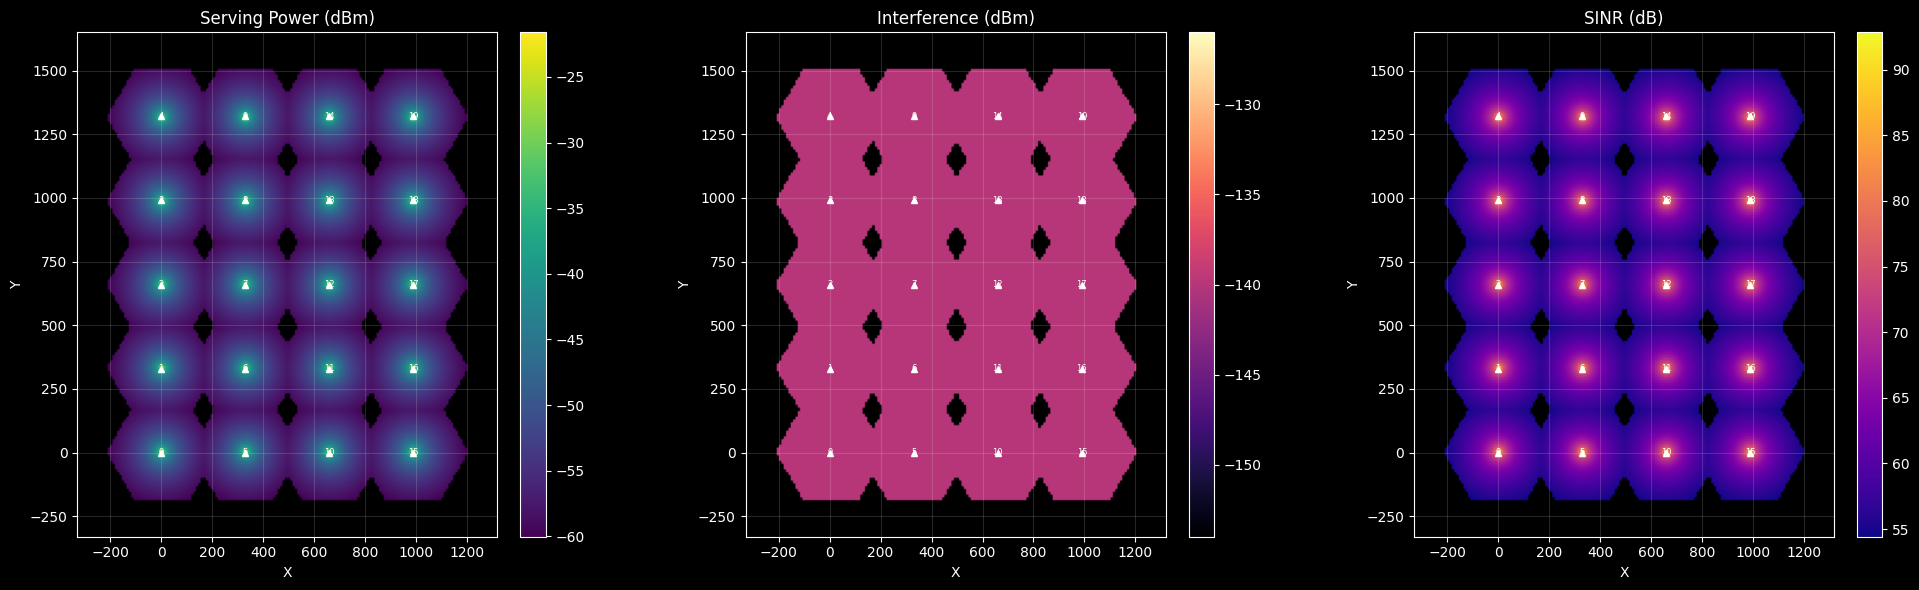

In [35]:
# ===============================
# Heat maps for 20 gNodeB network
# ===============================

import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Grid limits from gNB positions
# -------------------------------
all_x = [g.x for g in gnbs]
all_y = [g.y for g in gnbs]

margin = coverage_radius * 1.5
x_min, x_max = min(all_x) - margin, max(all_x) + margin
y_min, y_max = min(all_y) - margin, max(all_y) + margin

nx, ny = 180, 180
xs = np.linspace(x_min, x_max, nx)
ys = np.linspace(y_min, y_max, ny)
X, Y = np.meshgrid(xs, ys)

# -------------------------------
# Storage
# -------------------------------
serving_power_map = np.full((ny, nx), np.nan)
interference_map = np.full((ny, nx), np.nan)
sinr_map = np.full((ny, nx), np.nan)
best_gnb_map = np.full((ny, nx), -1)

# -------------------------------
# Compute maps
# -------------------------------
for iy in range(ny):
    for ix in range(nx):
        x = X[iy, ix]
        y = Y[iy, ix]

        best_idx = env._best_gnb(x, y)
        if best_idx is None:
            continue

        gnb = gnbs[best_idx]

        # fake temporary UE-like object
        class DummyUE:
            pass

        ue = DummyUE()
        ue.x = x
        ue.y = y
        ue.serving_gnb = best_idx

        sp = env.compute_serving_power_dbm(ue)
        interf = env.compute_interference_dbm(ue)
        sinr = env.compute_sinr_db(ue)

        serving_power_map[iy, ix] = sp
        interference_map[iy, ix] = interf if np.isfinite(interf) else -140
        sinr_map[iy, ix] = sinr
        best_gnb_map[iy, ix] = best_idx

# -------------------------------
# Plot
# -------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

maps = [
    (serving_power_map, "Serving Power (dBm)", "viridis"),
    (interference_map, "Interference (dBm)", "magma"),
    (sinr_map, "SINR (dB)", "plasma"),
]

for ax, (data, title, cmap) in zip(axes, maps):
    im = ax.imshow(
        data,
        extent=[x_min, x_max, y_min, y_max],
        origin='lower',
        aspect='equal',
        cmap=cmap
    )
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # gNB positions
    for i, g in enumerate(gnbs):
        ax.plot(g.x, g.y, 'w^', markersize=5)
        ax.text(g.x, g.y, str(i), color='white', fontsize=6, ha='center', va='center')

    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()

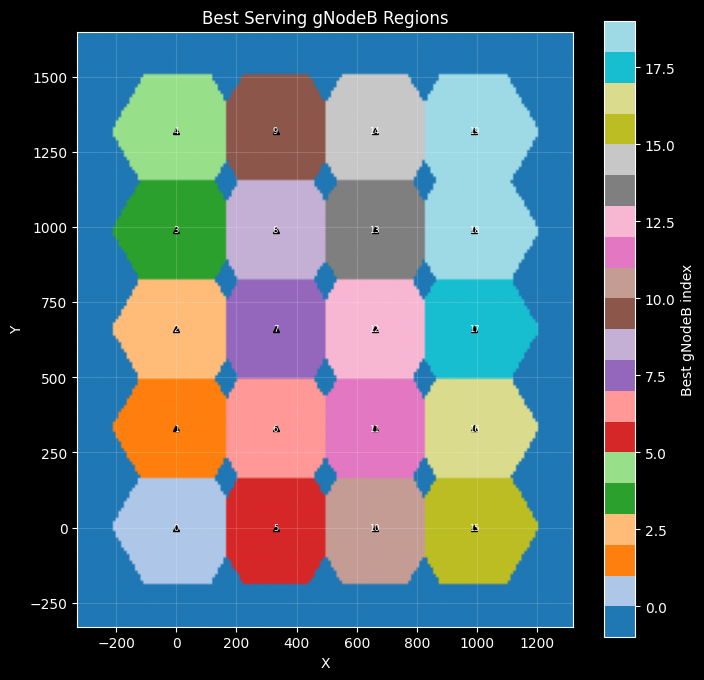

In [36]:
plt.figure(figsize=(8, 8))
plt.imshow(
    best_gnb_map,
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    aspect='equal',
    cmap='tab20'
)
plt.colorbar(label="Best gNodeB index")

for i, g in enumerate(gnbs):
    plt.plot(g.x, g.y, 'k^', markersize=5)
    plt.text(g.x, g.y, str(i), color='white', fontsize=6, ha='center', va='center')

plt.title("Best Serving gNodeB Regions")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(alpha=0.15)
plt.show()

In [37]:
env = MultiGNBWrapper(
    gnb_list=gnbs,
    handover_hysteresis=1.0,
    handover_ttt=2,
    verbose=False
)

obs, info = env.reset()
print("Obs shape:", obs.shape)
print(info)

Obs shape: (264,)
{'step': 0, 'n_gnbs': 20, 'n_tracked_ues': 0, 'n_connected_ues': 0, 'n_disconnected_ues': 0, 'ue_per_gnb': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'handover_count_total': 0, 'handover_count_step': 0, 'per_gnb_rewards': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'interference_model': 'same_carrier => interference, different_carrier => no_interference'}


In [38]:
ue_ids = []

xmin = min(g.x for g in gnbs)
xmax = max(g.x for g in gnbs)
ymin = min(g.y for g in gnbs)
ymax = max(g.y for g in gnbs)

for _ in range(N_UES):
    x = rng.uniform(xmin, xmax)
    y = rng.uniform(ymin, ymax)
    vx = rng.uniform(-30, 30)
    vy = rng.uniform(-30, 30)
    ue_ids.append(env.add_ue(x, y, vx, vy, slice_type="eMBB"))

print("UE count:", len(ue_ids))
print(env.get_ue_radio_metrics(ue_ids[0]))

UE count: 30
{'ue_id': 0, 'x': 766.2164880704037, 'y': 579.319540472709, 'slice_type': 'eMBB', 'serving_gnb': 12, 'serving_power_dbm': np.float64(-55.783432562246645), 'interference_dbm': -inf, 'noise_dbm': np.float64(-114.44727494896694), 'sinr_db': np.float64(58.663842386720276), 'connected': True}


In [39]:
steps = 100

trajectories = {uid: [] for uid in ue_ids}
serving = {uid: [] for uid in ue_ids}

for t in range(steps):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

    for uid in ue_ids:
        ue = env.get_ue(uid)
        trajectories[uid].append((ue.x, ue.y))
        serving[uid].append(ue.serving_gnb)

print("Total handovers:", len(env.handover_log))
print("Connected UEs:", env._count_connected_ues())
print("Disconnected UEs:", env._count_disconnected_ues())

Total handovers: 11
Connected UEs: 30
Disconnected UEs: 0


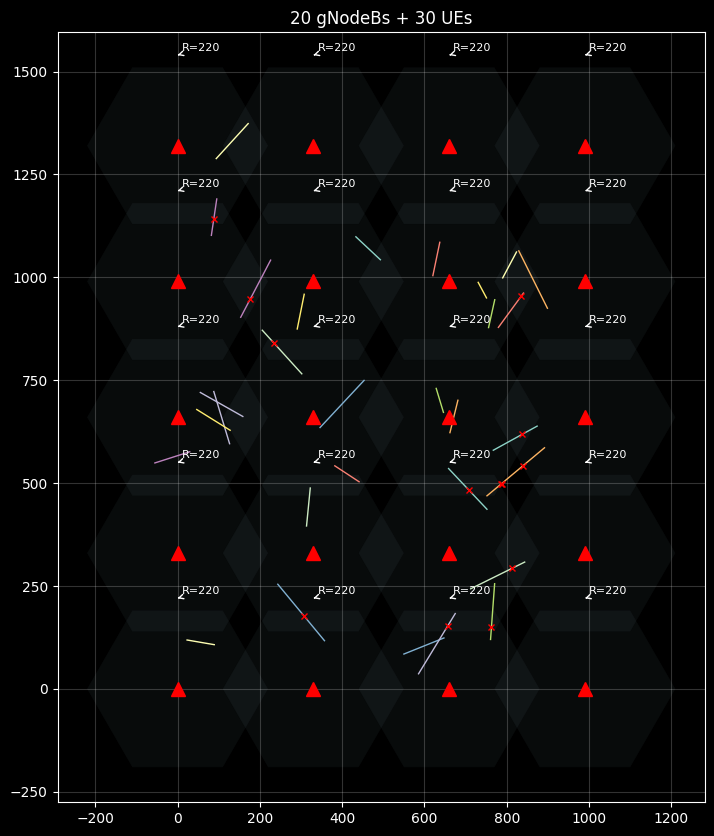

In [40]:
fig, ax = plt.subplots(figsize=(10, 10))

for g in gnbs:
    g.visualize_coverage(ax=ax, alpha=0.05, edge_color='black', linewidth=0.5)
    ax.plot(g.x, g.y, 'k.', markersize=3)

for uid in ue_ids:
    traj = np.array(trajectories[uid])
    ax.plot(traj[:, 0], traj[:, 1], linewidth=1)

    s = serving[uid]
    for t in range(1, len(s)):
        if s[t] != s[t - 1]:
            ax.plot(traj[t, 0], traj[t, 1], 'rx', markersize=5)

ax.set_title("20 gNodeBs + 30 UEs")
ax.set_aspect('equal')
ax.grid(alpha=0.2)
plt.show()

In [41]:
for uid in ue_ids[:5]:
    print(env.get_ue_radio_metrics(uid))

{'ue_id': 0, 'x': 873.7958640438134, 'y': 638.5299491905176, 'slice_type': 'eMBB', 'serving_gnb': 17, 'serving_power_dbm': np.float64(-54.73157258639442), 'interference_dbm': -inf, 'noise_dbm': np.float64(-114.44727494896694), 'sinr_db': np.float64(59.7157023625725), 'connected': True}
{'ue_id': 1, 'x': 171.57748500587937, 'y': 1373.640795743602, 'slice_type': 'eMBB', 'serving_gnb': 4, 'serving_power_dbm': np.float64(-58.37555950325287), 'interference_dbm': -inf, 'noise_dbm': np.float64(-114.44727494896694), 'sinr_db': np.float64(56.07171544571406), 'connected': True}
{'ue_id': 2, 'x': 88.07190361856436, 'y': 722.5389346767339, 'slice_type': 'eMBB', 'serving_gnb': 2, 'serving_power_dbm': np.float64(-53.95124266763456), 'interference_dbm': -inf, 'noise_dbm': np.float64(-114.44727494896694), 'sinr_db': np.float64(60.49603228133236), 'connected': True}
{'ue_id': 3, 'x': 620.450728528056, 'y': 1004.2169460529328, 'slice_type': 'eMBB', 'serving_gnb': 13, 'serving_power_dbm': np.float64(-45.

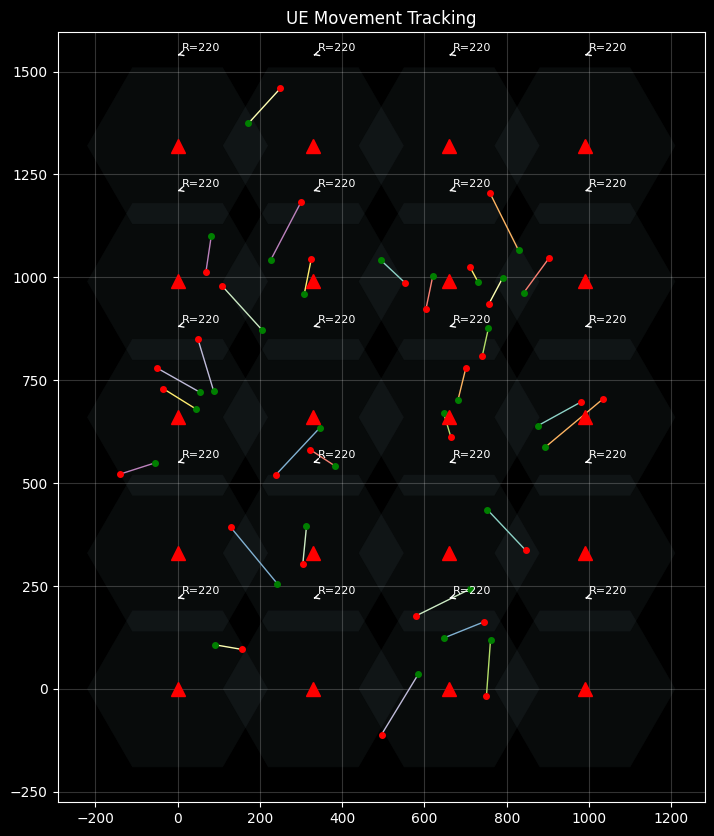

In [42]:
# Track UE movement over time
steps = 100

# Store positions of each UE at every step
ue_paths = {ue_id: [] for ue_id in ue_ids}

for t in range(steps):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

    for ue_id in ue_ids:
        ue = env.get_ue(ue_id)
        ue_paths[ue_id].append((ue.x, ue.y))

# Plot trajectories
fig, ax = plt.subplots(figsize=(10, 10))

# Plot gNB coverage
for g in gnbs:
    g.visualize_coverage(ax=ax, alpha=0.05, edge_color='black', linewidth=0.5)
    ax.plot(g.x, g.y, 'k.', markersize=3)

# Plot UE trajectories
for ue_id, path in ue_paths.items():
    path = np.array(path)
    ax.plot(path[:, 0], path[:, 1], linewidth=1, label=f'UE {ue_id}')
    ax.plot(path[0, 0], path[0, 1], 'go', markersize=4)   # start
    ax.plot(path[-1, 0], path[-1, 1], 'ro', markersize=4) # end

ax.set_title("UE Movement Tracking")
ax.set_aspect('equal')
ax.grid(alpha=0.2)
plt.show()

 UE moves →
    find best gNB →
        compare with current →
            if better enough (hysteresis) →
                wait TTT steps →
                    handover

In [43]:
# Show full handover history
print("Total handovers:", len(env.handover_log))

for i, event in enumerate(env.handover_log):
    print(
        f"{i:03d} | step={event['step']:3d} | "
        f"UE={event['ue_id']:2d} | "
        f"{event['from_gnb']} -> {event['to_gnb']} | "
        f"pos=({event['x']:.2f}, {event['y']:.2f})"
    )

Total handovers: 21
000 | step= 20 | UE=12 | 11 -> 10 | pos=(656.76, 153.44)
001 | step= 23 | UE=18 | 16 -> 11 | pos=(813.07, 293.06)
002 | step= 24 | UE= 5 | 11 -> 12 | pos=(785.81, 497.46)
003 | step= 31 | UE= 7 | 3 -> 8 | pos=(176.24, 946.51)
004 | step= 43 | UE=24 | 5 -> 6 | pos=(307.77, 176.67)
005 | step= 52 | UE=20 | 12 -> 11 | pos=(707.60, 483.48)
006 | step= 55 | UE=27 | 4 -> 3 | pos=(88.00, 1141.43)
007 | step= 65 | UE= 0 | 12 -> 17 | pos=(837.22, 618.40)
008 | step= 69 | UE=28 | 7 -> 8 | pos=(235.02, 839.46)
009 | step= 77 | UE= 6 | 11 -> 10 | pos=(762.81, 150.17)
010 | step= 91 | UE=13 | 13 -> 18 | pos=(835.68, 955.08)
011 | step=106 | UE= 1 | 4 -> 9 | pos=(177.06, 1379.65)
012 | step=111 | UE=25 | 18 -> 13 | pos=(820.83, 1081.26)
013 | step=121 | UE=10 | 8 -> 13 | pos=(506.08, 1030.46)
014 | step=154 | UE=28 | 8 -> 3 | pos=(152.60, 930.40)
015 | step=171 | UE=25 | 13 -> 14 | pos=(778.68, 1165.71)
016 | step=178 | UE=24 | 6 -> 1 | pos=(153.06, 363.74)
017 | step=188 | UE= 7

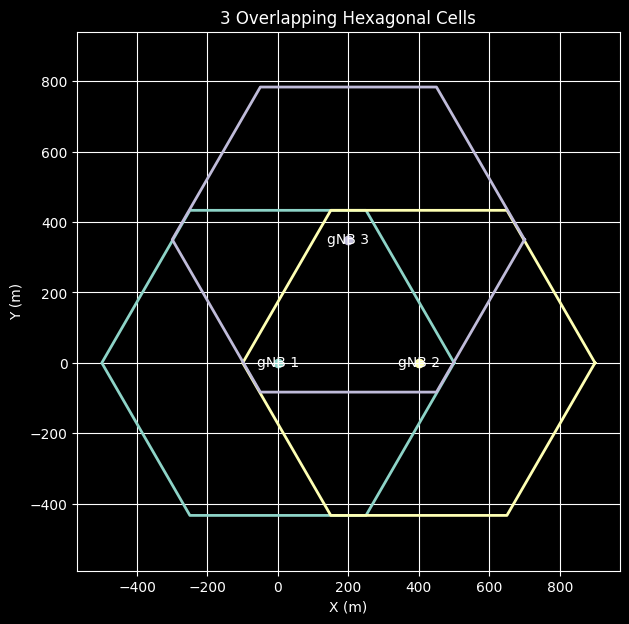

In [46]:
import matplotlib.pyplot as plt
from node_b import NodeB

# -----------------------------
# 1. Create 3 gNBs
# -----------------------------
gnb1 = NodeB(id=1, x=0,   y=0,   slices_l1=[], slots_per_step=1, n_prbs=50)
gnb2 = NodeB(id=2, x=400, y=0,   slices_l1=[], slots_per_step=1, n_prbs=50)
gnb3 = NodeB(id=3, x=200, y=350, slices_l1=[], slots_per_step=1, n_prbs=50)

gnbs = [gnb1, gnb2, gnb3]

# -----------------------------
# 2. Plot hexagonal cells
# -----------------------------
plt.figure(figsize=(7, 7))

for gnb in gnbs:
    # Get hexagon vertices
    vertices = gnb.vertices
    x_coords = [v[0] for v in vertices] + [vertices[0][0]]
    y_coords = [v[1] for v in vertices] + [vertices[0][1]]

    # Plot hexagon
    plt.plot(x_coords, y_coords, linewidth=2)

    # Plot center
    plt.scatter(gnb.x, gnb.y)
    plt.text(gnb.x, gnb.y, f"gNB {gnb.id}", ha='center', va='center')

# -----------------------------
# 3. Style
# -----------------------------
plt.title("3 Overlapping Hexagonal Cells")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.axis("equal")
plt.grid(True)

plt.show()

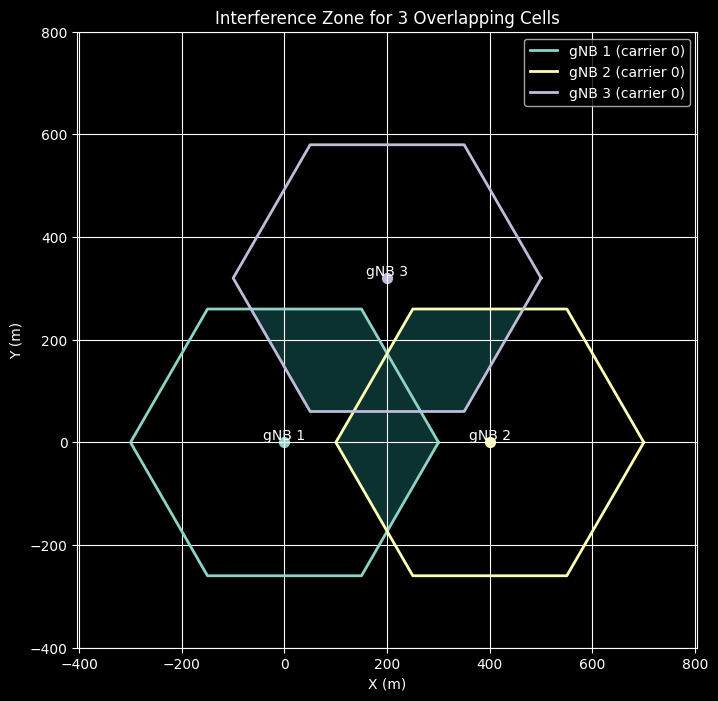

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from node_b import NodeB

# -------------------------------------------------
# 1. Create 3 gNBs
# -------------------------------------------------
gnb1 = NodeB(
    id=1, x=0, y=0,
    slices_l1=[], slots_per_step=1, n_prbs=50,
    coverage_radius=300,
    carrier_id=0
)

gnb2 = NodeB(
    id=2, x=400, y=0,
    slices_l1=[], slots_per_step=1, n_prbs=50,
    coverage_radius=300,
    carrier_id=0
)

gnb3 = NodeB(
    id=3, x=200, y=320,
    slices_l1=[], slots_per_step=1, n_prbs=50,
    coverage_radius=300,
    carrier_id=0   # put 1 here if you want it not to interfere with the others
)

gnbs = [gnb1, gnb2, gnb3]

# -------------------------------------------------
# 2. Build a grid over the area
# -------------------------------------------------
x_min, x_max = -400, 800
y_min, y_max = -400, 800
resolution = 500

x_vals = np.linspace(x_min, x_max, resolution)
y_vals = np.linspace(y_min, y_max, resolution)

coverage_count = np.zeros((resolution, resolution), dtype=int)

# -------------------------------------------------
# 3. Count how many same-carrier cells cover each point
# -------------------------------------------------
for iy, y in enumerate(y_vals):
    for ix, x in enumerate(x_vals):
        count = 0
        for gnb in gnbs:
            if gnb.is_point_in_coverage(x, y):
                count += 1
        coverage_count[iy, ix] = count

# Interference zone = covered by at least 2 cells
interference_zone = coverage_count >= 2

# -------------------------------------------------
# 4. Plot cells
# -------------------------------------------------
plt.figure(figsize=(8, 8))

for gnb in gnbs:
    vertices = gnb.vertices
    x_coords = [v[0] for v in vertices] + [vertices[0][0]]
    y_coords = [v[1] for v in vertices] + [vertices[0][1]]

    plt.plot(x_coords, y_coords, linewidth=2, label=f"gNB {gnb.id} (carrier {gnb.carrier_id})")
    plt.scatter(gnb.x, gnb.y, s=50)
    plt.text(gnb.x, gnb.y, f"gNB {gnb.id}", ha="center", va="bottom")

# -------------------------------------------------
# 5. Shade interference zone
# -------------------------------------------------
plt.contourf(
    x_vals,
    y_vals,
    interference_zone.astype(int),
    levels=[0.5, 1.5],
    alpha=0.35
)

# -------------------------------------------------
# 6. Styling
# -------------------------------------------------
plt.title("Interference Zone for 3 Overlapping Cells")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

# Interferance Heatmap

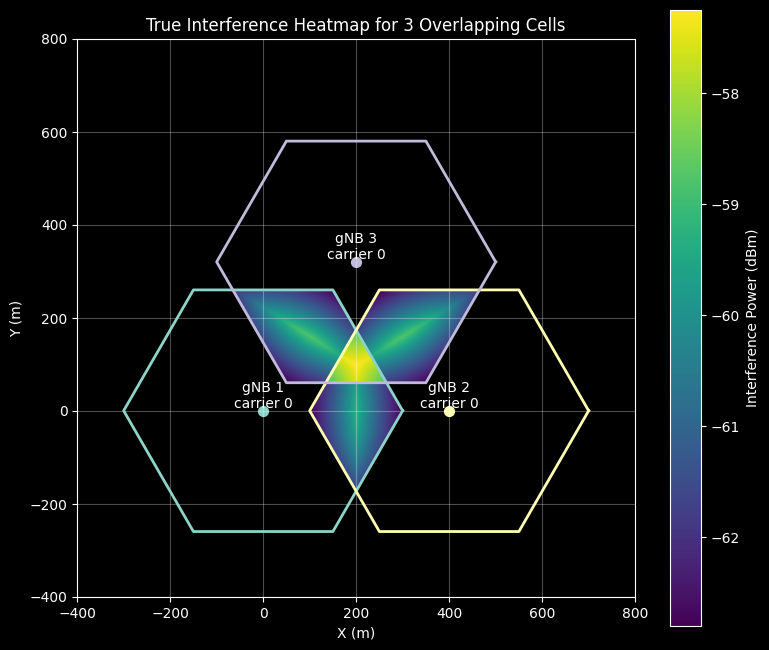

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from node_b import NodeB

# -------------------------------------------------
# 1. Create 3 gNBs
# -------------------------------------------------
gnb1 = NodeB(
    id=1, x=0, y=0,
    slices_l1=[], slots_per_step=1, n_prbs=50,
    coverage_radius=300,
    carrier_id=0,
    tx_power_dbm=30.0,
    center_frequency_hz=3.5e9,
    noise_figure_db=7.0
)

gnb2 = NodeB(
    id=2, x=400, y=0,
    slices_l1=[], slots_per_step=1, n_prbs=50,
    coverage_radius=300,
    carrier_id=0,
    tx_power_dbm=30.0,
    center_frequency_hz=3.5e9,
    noise_figure_db=7.0
)

gnb3 = NodeB(
    id=3, x=200, y=320,
    slices_l1=[], slots_per_step=1, n_prbs=50,
    coverage_radius=300,
    carrier_id=0,   # change to 1 if you want cell 3 on another carrier
    tx_power_dbm=30.0,
    center_frequency_hz=3.5e9,
    noise_figure_db=7.0
)

gnbs = [gnb1, gnb2, gnb3]

# -------------------------------------------------
# 2. Grid definition
# -------------------------------------------------
x_min, x_max = -400, 800
y_min, y_max = -400, 800
resolution = 400

x_vals = np.linspace(x_min, x_max, resolution)
y_vals = np.linspace(y_min, y_max, resolution)

interference_map_dbm = np.full((resolution, resolution), np.nan)
serving_cell_map = np.full((resolution, resolution), -1)

# -------------------------------------------------
# 3. Helpers
# -------------------------------------------------
def dbm_to_watts(p_dbm):
    if not np.isfinite(p_dbm):
        return 0.0
    return 10 ** ((p_dbm - 30.0) / 10.0)

def watts_to_dbm(p_watts):
    if p_watts <= 0:
        return -np.inf
    return 10 * np.log10(p_watts) + 30.0

# -------------------------------------------------
# 4. Compute true interference at each point
# -------------------------------------------------
for iy, y in enumerate(y_vals):
    for ix, x in enumerate(x_vals):
        rx_dbm_list = []
        rx_watts_list = []

        # received power from each gNB
        for gnb in gnbs:
            p_dbm = gnb.get_received_power_dbm(x, y)
            rx_dbm_list.append(p_dbm)
            rx_watts_list.append(dbm_to_watts(p_dbm))

        rx_watts = np.array(rx_watts_list, dtype=float)

        # no coverage from any cell
        if np.all(rx_watts == 0):
            continue

        # strongest cell = serving cell
        serving_idx = int(np.argmax(rx_watts))
        serving_gnb = gnbs[serving_idx]
        serving_cell_map[iy, ix] = serving_idx

        # sum interference only from other cells on same carrier
        interference_watts = 0.0
        for k, gnb in enumerate(gnbs):
            if k == serving_idx:
                continue
            if serving_gnb.uses_same_carrier(gnb):
                interference_watts += rx_watts[k]

        interference_map_dbm[iy, ix] = watts_to_dbm(interference_watts)

# -------------------------------------------------
# 5. Plot
# -------------------------------------------------
plt.figure(figsize=(9, 8))

# Heatmap
img = plt.imshow(
    interference_map_dbm,
    extent=[x_min, x_max, y_min, y_max],
    origin="lower",
    aspect="equal"
)

plt.colorbar(img, label="Interference Power (dBm)")

# Plot cell hexagons and centers
for gnb in gnbs:
    vertices = gnb.vertices
    x_hex = [v[0] for v in vertices] + [vertices[0][0]]
    y_hex = [v[1] for v in vertices] + [vertices[0][1]]

    plt.plot(x_hex, y_hex, linewidth=2)
    plt.scatter(gnb.x, gnb.y, s=50)
    plt.text(
        gnb.x, gnb.y,
        f"gNB {gnb.id}\ncarrier {gnb.carrier_id}",
        ha="center",
        va="bottom"
    )

plt.title("True Interference Heatmap for 3 Overlapping Cells")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.grid(True, alpha=0.3)
plt.show()

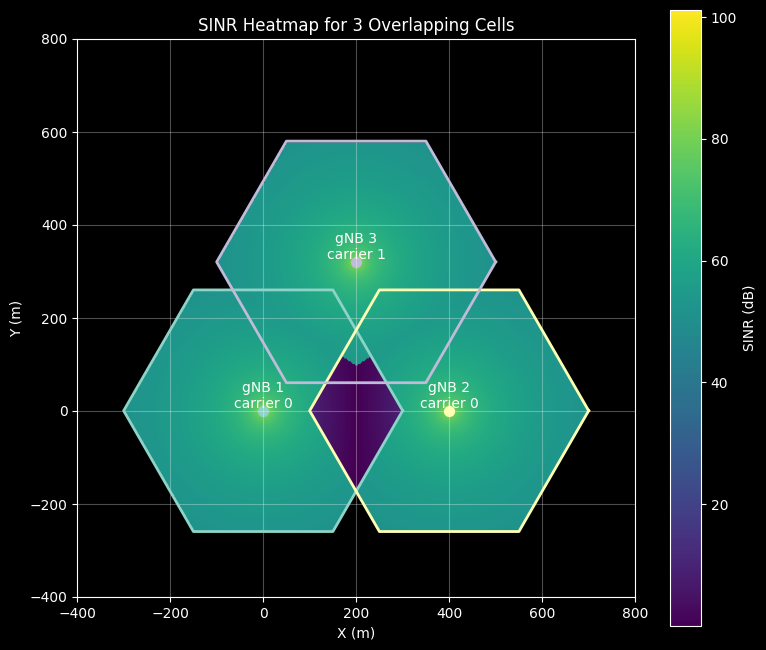

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from node_b import NodeB

# =========================================================
# 1. Create 3 cells
# =========================================================
gnb1 = NodeB(
    id=1, x=0, y=0,
    slices_l1=[], slots_per_step=1, n_prbs=50,
    coverage_radius=300,
    carrier_id=0,
    tx_power_dbm=30.0,
    center_frequency_hz=3.5e9,
    noise_figure_db=7.0
)

gnb2 = NodeB(
    id=2, x=400, y=0,
    slices_l1=[], slots_per_step=1, n_prbs=50,
    coverage_radius=300,
    carrier_id=0,
    tx_power_dbm=30.0,
    center_frequency_hz=3.5e9,
    noise_figure_db=7.0
)

gnb3 = NodeB(
    id=3, x=200, y=320,
    slices_l1=[], slots_per_step=1, n_prbs=50,
    coverage_radius=300,
    carrier_id=1,   # change to 1 to reduce interference from cell 3
    tx_power_dbm=30.0,
    center_frequency_hz=3.5e9,
    noise_figure_db=7.0
)

gnbs = [gnb1, gnb2, gnb3]

# =========================================================
# 2. Helpers
# =========================================================
def dbm_to_watts(p_dbm):
    if not np.isfinite(p_dbm):
        return 0.0
    return 10 ** ((p_dbm - 30.0) / 10.0)

# =========================================================
# 3. Grid
# =========================================================
x_min, x_max = -400, 800
y_min, y_max = -400, 800
resolution = 400

x_vals = np.linspace(x_min, x_max, resolution)
y_vals = np.linspace(y_min, y_max, resolution)

sinr_map = np.full((resolution, resolution), np.nan)
serving_map = np.full((resolution, resolution), -1)

# =========================================================
# 4. Compute SINR
# =========================================================
for iy, y in enumerate(y_vals):
    for ix, x in enumerate(x_vals):
        rx_dbm = np.array([gnb.get_received_power_dbm(x, y) for gnb in gnbs], dtype=float)
        rx_watts = np.array([dbm_to_watts(p) for p in rx_dbm], dtype=float)

        # no coverage
        if np.all(rx_watts == 0):
            continue

        # strongest cell = serving cell
        serving_idx = int(np.argmax(rx_watts))
        serving_gnb = gnbs[serving_idx]
        signal_watts = rx_watts[serving_idx]
        serving_map[iy, ix] = serving_idx

        # interference only from same-carrier non-serving cells
        interference_watts = 0.0
        for k, gnb in enumerate(gnbs):
            if k != serving_idx and serving_gnb.uses_same_carrier(gnb):
                interference_watts += rx_watts[k]

        # thermal noise
        noise_dbm = serving_gnb.get_noise_power_dbm()
        noise_watts = dbm_to_watts(noise_dbm)

        sinr_linear = signal_watts / (interference_watts + noise_watts)
        sinr_db = 10 * np.log10(sinr_linear)
        sinr_map[iy, ix] = sinr_db

# =========================================================
# 5. Plot
# =========================================================
plt.figure(figsize=(9, 8))

img = plt.imshow(
    sinr_map,
    extent=[x_min, x_max, y_min, y_max],
    origin="lower",
    aspect="equal"
)
plt.colorbar(img, label="SINR (dB)")

for gnb in gnbs:
    vertices = gnb.vertices
    x_hex = [v[0] for v in vertices] + [vertices[0][0]]
    y_hex = [v[1] for v in vertices] + [vertices[0][1]]
    plt.plot(x_hex, y_hex, linewidth=2)
    plt.scatter(gnb.x, gnb.y, s=50)
    plt.text(gnb.x, gnb.y, f"gNB {gnb.id}\ncarrier {gnb.carrier_id}", ha="center", va="bottom")

plt.title("SINR Heatmap for 3 Overlapping Cells")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.grid(True, alpha=0.3)
plt.show()

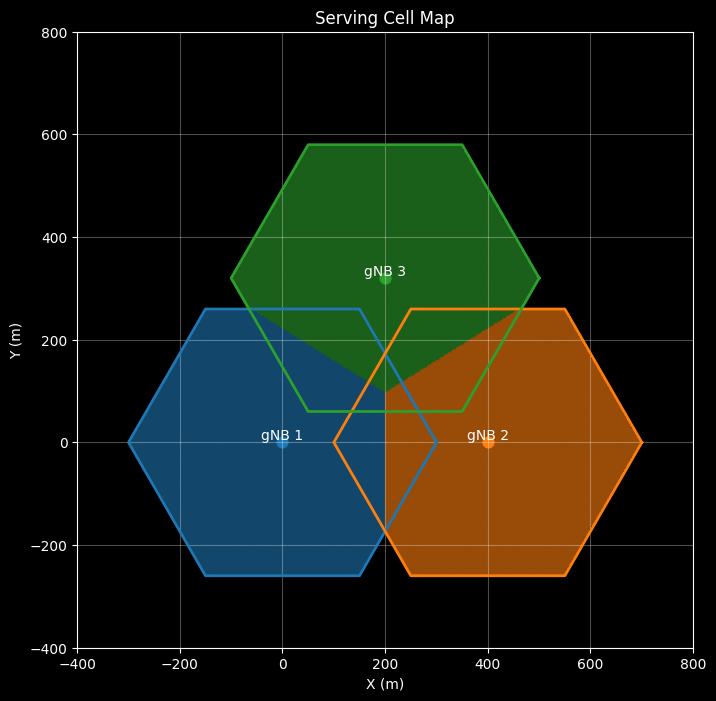

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from node_b import NodeB

# =========================================================
# 1. Create 3 cells
# =========================================================
gnb1 = NodeB(
    id=1, x=0, y=0,
    slices_l1=[], slots_per_step=1, n_prbs=50,
    coverage_radius=300,
    carrier_id=1,
    tx_power_dbm=30.0,
    center_frequency_hz=3.5e9,
    noise_figure_db=7.0
)

gnb2 = NodeB(
    id=2, x=400, y=0,
    slices_l1=[], slots_per_step=1, n_prbs=50,
    coverage_radius=300,
    carrier_id=1,
    tx_power_dbm=30.0,
    center_frequency_hz=3.5e9,
    noise_figure_db=7.0
)

gnb3 = NodeB(
    id=3, x=200, y=320,
    slices_l1=[], slots_per_step=1, n_prbs=50,
    coverage_radius=300,
    carrier_id=0,
    tx_power_dbm=30.0,
    center_frequency_hz=3.5e9,
    noise_figure_db=7.0
)

gnbs = [gnb1, gnb2, gnb3]

# =========================================================
# 2. Grid
# =========================================================
x_min, x_max = -400, 800
y_min, y_max = -400, 800
resolution = 400

x_vals = np.linspace(x_min, x_max, resolution)
y_vals = np.linspace(y_min, y_max, resolution)

serving_map = np.full((resolution, resolution), -1, dtype=int)
best_power_map = np.full((resolution, resolution), np.nan)

# =========================================================
# 3. Compute serving cell
# =========================================================
for iy, y in enumerate(y_vals):
    for ix, x in enumerate(x_vals):
        rx_dbm = np.array([gnb.get_received_power_dbm(x, y) for gnb in gnbs], dtype=float)

        if np.all(~np.isfinite(rx_dbm)):
            continue

        serving_idx = int(np.nanargmax(rx_dbm))
        serving_map[iy, ix] = serving_idx
        best_power_map[iy, ix] = rx_dbm[serving_idx]

# =========================================================
# 4. Plot
# =========================================================
cmap = ListedColormap(["tab:blue", "tab:orange", "tab:green"])
masked_serving = np.ma.masked_where(serving_map < 0, serving_map)

plt.figure(figsize=(9, 8))

plt.imshow(
    masked_serving,
    extent=[x_min, x_max, y_min, y_max],
    origin="lower",
    aspect="equal",
    cmap=cmap,
    alpha=0.6
)

# draw cell borders and centers
for idx, gnb in enumerate(gnbs):
    vertices = gnb.vertices
    x_hex = [v[0] for v in vertices] + [vertices[0][0]]
    y_hex = [v[1] for v in vertices] + [vertices[0][1]]

    plt.plot(x_hex, y_hex, linewidth=2, color=cmap(idx))
    plt.scatter(gnb.x, gnb.y, s=60, color=cmap(idx))
    plt.text(gnb.x, gnb.y, f"gNB {gnb.id}", ha="center", va="bottom")

plt.title("Serving Cell Map")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.grid(True, alpha=0.3)
plt.show()

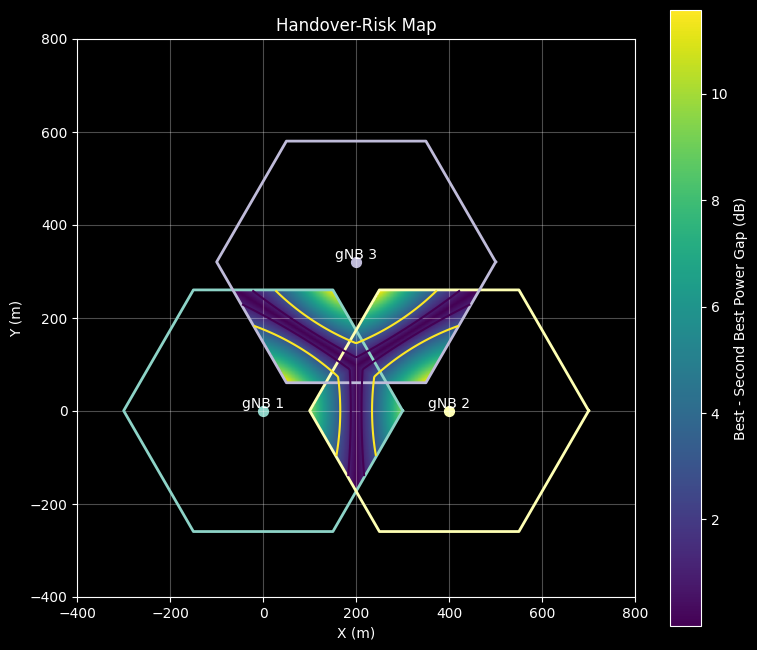

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from node_b import NodeB

# =========================================================
# 1. Create 3 cells
# =========================================================
gnb1 = NodeB(
    id=1, x=0, y=0,
    slices_l1=[], slots_per_step=1, n_prbs=50,
    coverage_radius=300,
    carrier_id=0,
    tx_power_dbm=30.0,
    center_frequency_hz=3.5e9,
    noise_figure_db=7.0
)

gnb2 = NodeB(
    id=2, x=400, y=0,
    slices_l1=[], slots_per_step=1, n_prbs=50,
    coverage_radius=300,
    carrier_id=0,
    tx_power_dbm=30.0,
    center_frequency_hz=3.5e9,
    noise_figure_db=7.0
)

gnb3 = NodeB(
    id=3, x=200, y=320,
    slices_l1=[], slots_per_step=1, n_prbs=50,
    coverage_radius=300,
    carrier_id=0,
    tx_power_dbm=30.0,
    center_frequency_hz=3.5e9,
    noise_figure_db=7.0
)

gnbs = [gnb1, gnb2, gnb3]

# =========================================================
# 2. Grid
# =========================================================
x_min, x_max = -400, 800
y_min, y_max = -400, 800
resolution = 400

x_vals = np.linspace(x_min, x_max, resolution)
y_vals = np.linspace(y_min, y_max, resolution)

gap_map = np.full((resolution, resolution), np.nan)

# =========================================================
# 3. Compute strongest-second strongest power gap
# =========================================================
for iy, y in enumerate(y_vals):
    for ix, x in enumerate(x_vals):
        rx_dbm = np.array([gnb.get_received_power_dbm(x, y) for gnb in gnbs], dtype=float)

        valid = np.isfinite(rx_dbm)
        valid_powers = rx_dbm[valid]

        if len(valid_powers) < 2:
            continue

        sorted_powers = np.sort(valid_powers)[::-1]
        best_dbm = sorted_powers[0]
        second_dbm = sorted_powers[1]

        gap_map[iy, ix] = best_dbm - second_dbm

# =========================================================
# 4. Plot
# =========================================================
plt.figure(figsize=(9, 8))

img = plt.imshow(
    gap_map,
    extent=[x_min, x_max, y_min, y_max],
    origin="lower",
    aspect="equal"
)
plt.colorbar(img, label="Best - Second Best Power Gap (dB)")

for gnb in gnbs:
    vertices = gnb.vertices
    x_hex = [v[0] for v in vertices] + [vertices[0][0]]
    y_hex = [v[1] for v in vertices] + [vertices[0][1]]
    plt.plot(x_hex, y_hex, linewidth=2)
    plt.scatter(gnb.x, gnb.y, s=50)
    plt.text(gnb.x, gnb.y, f"gNB {gnb.id}", ha="center", va="bottom")

# optional contour lines for risky zones
plt.contour(
    x_vals,
    y_vals,
    gap_map,
    levels=[1, 3],
    linewidths=1.5
)

plt.title("Handover-Risk Map")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.grid(True, alpha=0.3)
plt.show()

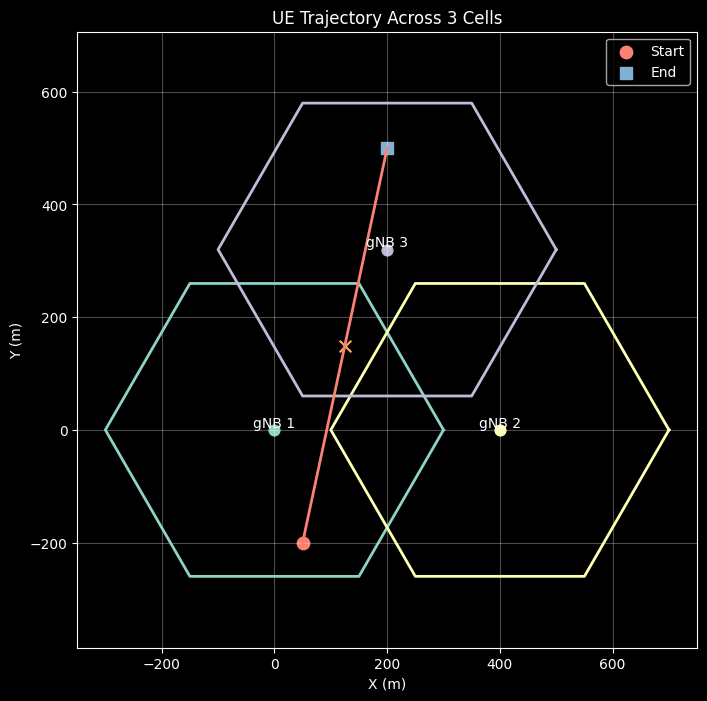

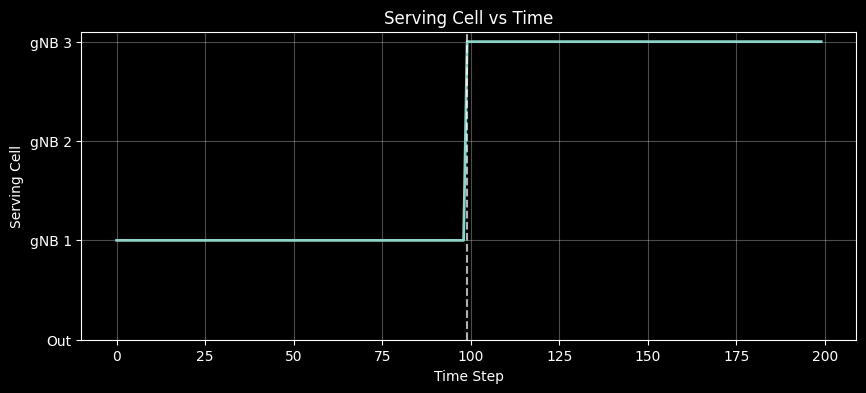

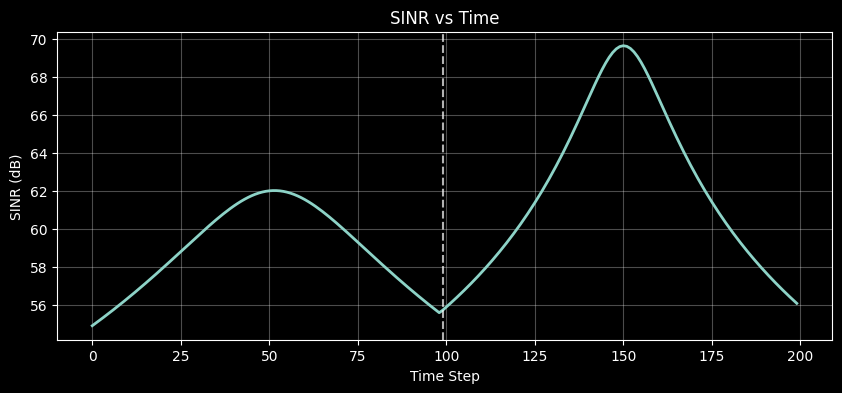

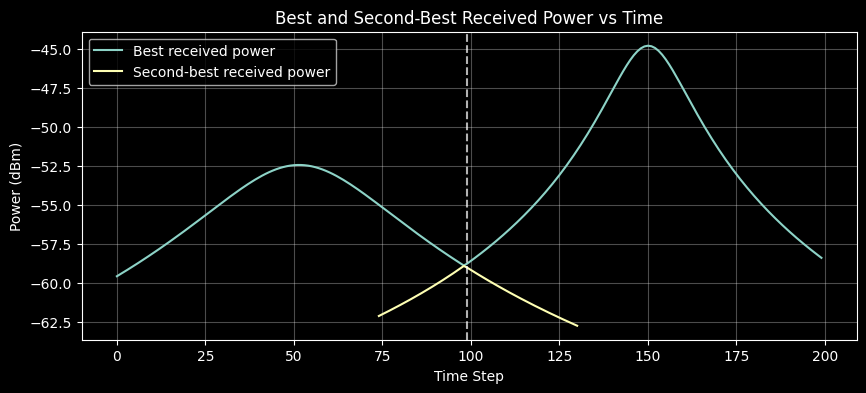

Number of handovers: 1
Handover steps: [99]


In [58]:
import numpy as np
import matplotlib.pyplot as plt
from node_b import NodeB

# =========================================================
# 1. Create 3 cells
# =========================================================
gnb1 = NodeB(
    id=1, x=0, y=0,
    slices_l1=[], slots_per_step=1, n_prbs=50,
    coverage_radius=300,
    carrier_id=0,
    tx_power_dbm=30.0,
    center_frequency_hz=3.5e9,
    noise_figure_db=7.0
)

gnb2 = NodeB(
    id=2, x=400, y=0,
    slices_l1=[], slots_per_step=1, n_prbs=50,
    coverage_radius=300,
    carrier_id=0,
    tx_power_dbm=30.0,
    center_frequency_hz=3.5e9,
    noise_figure_db=7.0
)

gnb3 = NodeB(
    id=3, x=200, y=320,
    slices_l1=[], slots_per_step=1, n_prbs=50,
    coverage_radius=300,
    carrier_id=1,   # change to 1 to test carrier reuse impact
    tx_power_dbm=30.0,
    center_frequency_hz=3.5e9,
    noise_figure_db=7.0
)

gnbs = [gnb1, gnb2, gnb3]

# =========================================================
# 2. Helper functions
# =========================================================
def dbm_to_watts(p_dbm):
    if not np.isfinite(p_dbm):
        return 0.0
    return 10 ** ((p_dbm - 30.0) / 10.0)

def compute_serving_cell_and_sinr(x, y, gnbs):
    rx_dbm = np.array([gnb.get_received_power_dbm(x, y) for gnb in gnbs], dtype=float)
    rx_watts = np.array([dbm_to_watts(p) for p in rx_dbm], dtype=float)

    if np.all(rx_watts == 0):
        return None, np.nan, rx_dbm

    serving_idx = int(np.argmax(rx_watts))
    serving_gnb = gnbs[serving_idx]

    signal_watts = rx_watts[serving_idx]

    interference_watts = 0.0
    for k, gnb in enumerate(gnbs):
        if k != serving_idx and serving_gnb.uses_same_carrier(gnb):
            interference_watts += rx_watts[k]

    noise_dbm = serving_gnb.get_noise_power_dbm()
    noise_watts = dbm_to_watts(noise_dbm)

    sinr_linear = signal_watts / (interference_watts + noise_watts)
    sinr_db = 10 * np.log10(sinr_linear)

    return serving_idx, sinr_db, rx_dbm

# =========================================================
# 3. Define one moving UE trajectory
# =========================================================
n_steps = 200

# Straight path crossing the 3-cell overlap region
x_start, y_start = 50, -200
x_end, y_end = 200, 500

x_traj = np.linspace(x_start, x_end, n_steps)
y_traj = np.linspace(y_start, y_end, n_steps)

serving_cells = []
sinr_values = []
best_powers = []
second_best_powers = []

for x, y in zip(x_traj, y_traj):
    serving_idx, sinr_db, rx_dbm = compute_serving_cell_and_sinr(x, y, gnbs)
    serving_cells.append(-1 if serving_idx is None else serving_idx)
    sinr_values.append(sinr_db)

    valid = rx_dbm[np.isfinite(rx_dbm)]
    if len(valid) > 0:
        valid_sorted = np.sort(valid)[::-1]
        best_powers.append(valid_sorted[0])
        second_best_powers.append(valid_sorted[1] if len(valid_sorted) > 1 else np.nan)
    else:
        best_powers.append(np.nan)
        second_best_powers.append(np.nan)

serving_cells = np.array(serving_cells)
sinr_values = np.array(sinr_values)
best_powers = np.array(best_powers)
second_best_powers = np.array(second_best_powers)

# Handover instants
handover_steps = []
for t in range(1, len(serving_cells)):
    if serving_cells[t] != serving_cells[t - 1]:
        if serving_cells[t] != -1 and serving_cells[t - 1] != -1:
            handover_steps.append(t)

# =========================================================
# 4. Plot trajectory on cell map
# =========================================================
plt.figure(figsize=(8, 8))

for gnb in gnbs:
    vertices = gnb.vertices
    x_hex = [v[0] for v in vertices] + [vertices[0][0]]
    y_hex = [v[1] for v in vertices] + [vertices[0][1]]
    plt.plot(x_hex, y_hex, linewidth=2)
    plt.scatter(gnb.x, gnb.y, s=60)
    plt.text(gnb.x, gnb.y, f"gNB {gnb.id}", ha="center", va="bottom")

plt.plot(x_traj, y_traj, linewidth=2)
plt.scatter(x_traj[0], y_traj[0], s=80, marker='o', label="Start")
plt.scatter(x_traj[-1], y_traj[-1], s=80, marker='s', label="End")

for t in handover_steps:
    plt.scatter(x_traj[t], y_traj[t], s=70, marker='x')

plt.title("UE Trajectory Across 3 Cells")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# =========================================================
# 5. Plot serving cell over time
# =========================================================
plt.figure(figsize=(10, 4))
plt.plot(serving_cells + 1, linewidth=2)  # +1 so labels match gNB numbering
for t in handover_steps:
    plt.axvline(t, linestyle='--', alpha=0.7)
plt.yticks([0, 1, 2, 3], ["Out", "gNB 1", "gNB 2", "gNB 3"])
plt.title("Serving Cell vs Time")
plt.xlabel("Time Step")
plt.ylabel("Serving Cell")
plt.grid(True, alpha=0.3)
plt.show()

# =========================================================
# 6. Plot SINR over time
# =========================================================
plt.figure(figsize=(10, 4))
plt.plot(sinr_values, linewidth=2)
for t in handover_steps:
    plt.axvline(t, linestyle='--', alpha=0.7)
plt.title("SINR vs Time")
plt.xlabel("Time Step")
plt.ylabel("SINR (dB)")
plt.grid(True, alpha=0.3)
plt.show()

# =========================================================
# 7. Optional: strongest and second-strongest power
# =========================================================
plt.figure(figsize=(10, 4))
plt.plot(best_powers, label="Best received power")
plt.plot(second_best_powers, label="Second-best received power")
for t in handover_steps:
    plt.axvline(t, linestyle='--', alpha=0.7)
plt.title("Best and Second-Best Received Power vs Time")
plt.xlabel("Time Step")
plt.ylabel("Power (dBm)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("Number of handovers:", len(handover_steps))
print("Handover steps:", handover_steps)

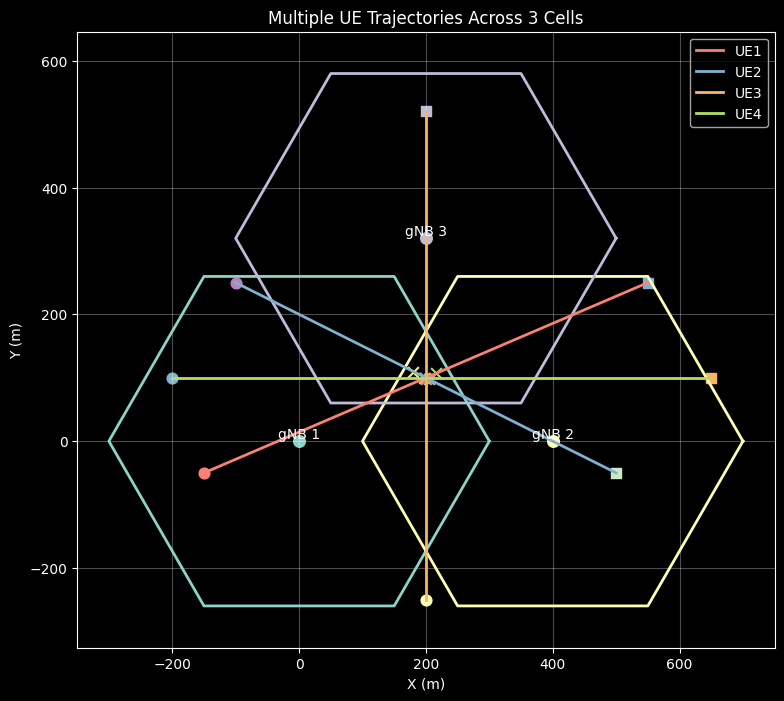

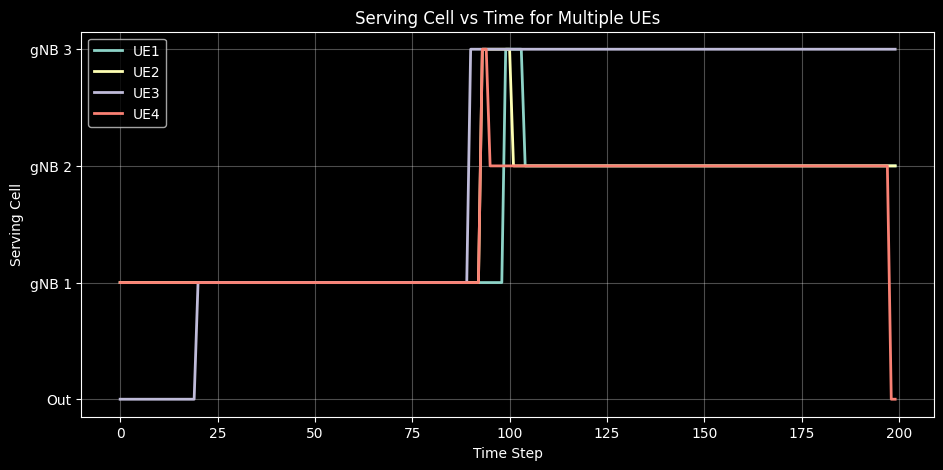

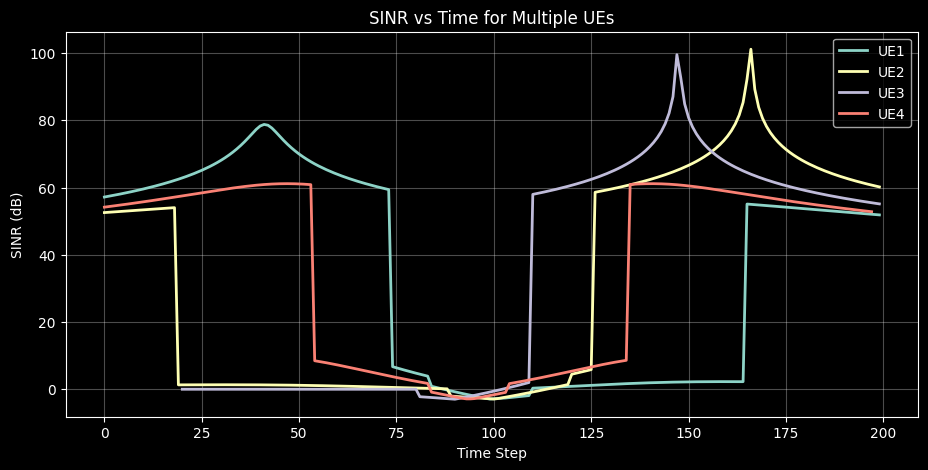

UE1: handovers=2, mean SINR=34.10 dB
UE2: handovers=2, mean SINR=30.43 dB
UE3: handovers=1, mean SINR=32.24 dB
UE4: handovers=2, mean SINR=35.63 dB


In [59]:
import numpy as np
import matplotlib.pyplot as plt
from node_b import NodeB

# =========================================================
# 1. Create 3 cells
# =========================================================
gnb1 = NodeB(
    id=1, x=0, y=0,
    slices_l1=[], slots_per_step=1, n_prbs=50,
    coverage_radius=300,
    carrier_id=0,
    tx_power_dbm=30.0,
    center_frequency_hz=3.5e9,
    noise_figure_db=7.0
)

gnb2 = NodeB(
    id=2, x=400, y=0,
    slices_l1=[], slots_per_step=1, n_prbs=50,
    coverage_radius=300,
    carrier_id=0,
    tx_power_dbm=30.0,
    center_frequency_hz=3.5e9,
    noise_figure_db=7.0
)

gnb3 = NodeB(
    id=3, x=200, y=320,
    slices_l1=[], slots_per_step=1, n_prbs=50,
    coverage_radius=300,
    carrier_id=0,   # change to 1 to test carrier reuse
    tx_power_dbm=30.0,
    center_frequency_hz=3.5e9,
    noise_figure_db=7.0
)

gnbs = [gnb1, gnb2, gnb3]

# =========================================================
# 2. Helpers
# =========================================================
def dbm_to_watts(p_dbm):
    if not np.isfinite(p_dbm):
        return 0.0
    return 10 ** ((p_dbm - 30.0) / 10.0)

def compute_serving_cell_and_sinr(x, y, gnbs):
    rx_dbm = np.array([gnb.get_received_power_dbm(x, y) for gnb in gnbs], dtype=float)
    rx_watts = np.array([dbm_to_watts(p) for p in rx_dbm], dtype=float)

    if np.all(rx_watts == 0):
        return -1, np.nan, rx_dbm

    serving_idx = int(np.argmax(rx_watts))
    serving_gnb = gnbs[serving_idx]

    signal_watts = rx_watts[serving_idx]

    interference_watts = 0.0
    for k, gnb in enumerate(gnbs):
        if k != serving_idx and serving_gnb.uses_same_carrier(gnb):
            interference_watts += rx_watts[k]

    noise_dbm = serving_gnb.get_noise_power_dbm()
    noise_watts = dbm_to_watts(noise_dbm)

    sinr_linear = signal_watts / (interference_watts + noise_watts)
    sinr_db = 10 * np.log10(sinr_linear)

    return serving_idx, sinr_db, rx_dbm

# =========================================================
# 3. Define multiple UE trajectories
# =========================================================
n_steps = 200

ue_specs = [
    {"name": "UE1", "start": (-150, -50), "end": (550, 250)},
    {"name": "UE2", "start": (-100, 250), "end": (500, -50)},
    {"name": "UE3", "start": (200, -250), "end": (200, 520)},
    {"name": "UE4", "start": (-200, 100), "end": (650, 100)},
]

results = []

for spec in ue_specs:
    x_traj = np.linspace(spec["start"][0], spec["end"][0], n_steps)
    y_traj = np.linspace(spec["start"][1], spec["end"][1], n_steps)

    serving_cells = []
    sinr_values = []
    handover_steps = []

    for t, (x, y) in enumerate(zip(x_traj, y_traj)):
        serving_idx, sinr_db, _ = compute_serving_cell_and_sinr(x, y, gnbs)
        serving_cells.append(serving_idx)
        sinr_values.append(sinr_db)

        if t > 0 and serving_cells[t] != serving_cells[t - 1]:
            if serving_cells[t] != -1 and serving_cells[t - 1] != -1:
                handover_steps.append(t)

    results.append({
        "name": spec["name"],
        "x_traj": x_traj,
        "y_traj": y_traj,
        "serving_cells": np.array(serving_cells),
        "sinr_values": np.array(sinr_values),
        "handover_steps": handover_steps
    })

# =========================================================
# 4. Plot trajectories on cell map
# =========================================================
plt.figure(figsize=(9, 8))

for gnb in gnbs:
    vertices = gnb.vertices
    x_hex = [v[0] for v in vertices] + [vertices[0][0]]
    y_hex = [v[1] for v in vertices] + [vertices[0][1]]
    plt.plot(x_hex, y_hex, linewidth=2)
    plt.scatter(gnb.x, gnb.y, s=70)
    plt.text(gnb.x, gnb.y, f"gNB {gnb.id}", ha="center", va="bottom")

for res in results:
    plt.plot(res["x_traj"], res["y_traj"], linewidth=2, label=res["name"])
    plt.scatter(res["x_traj"][0], res["y_traj"][0], s=60, marker='o')
    plt.scatter(res["x_traj"][-1], res["y_traj"][-1], s=60, marker='s')

    for t in res["handover_steps"]:
        plt.scatter(res["x_traj"][t], res["y_traj"][t], s=60, marker='x')

plt.title("Multiple UE Trajectories Across 3 Cells")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# =========================================================
# 5. Plot serving cell vs time for all UEs
# =========================================================
plt.figure(figsize=(11, 5))

for res in results:
    plt.plot(res["serving_cells"] + 1, linewidth=2, label=res["name"])

plt.yticks([0, 1, 2, 3], ["Out", "gNB 1", "gNB 2", "gNB 3"])
plt.title("Serving Cell vs Time for Multiple UEs")
plt.xlabel("Time Step")
plt.ylabel("Serving Cell")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# =========================================================
# 6. Plot SINR vs time for all UEs
# =========================================================
plt.figure(figsize=(11, 5))

for res in results:
    plt.plot(res["sinr_values"], linewidth=2, label=res["name"])

plt.title("SINR vs Time for Multiple UEs")
plt.xlabel("Time Step")
plt.ylabel("SINR (dB)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# =========================================================
# 7. Print summary
# =========================================================
for res in results:
    valid_sinr = res["sinr_values"][np.isfinite(res["sinr_values"])]
    mean_sinr = np.mean(valid_sinr) if len(valid_sinr) > 0 else np.nan
    print(
        f"{res['name']}: "
        f"handovers={len(res['handover_steps'])}, "
        f"mean SINR={mean_sinr:.2f} dB"
    )

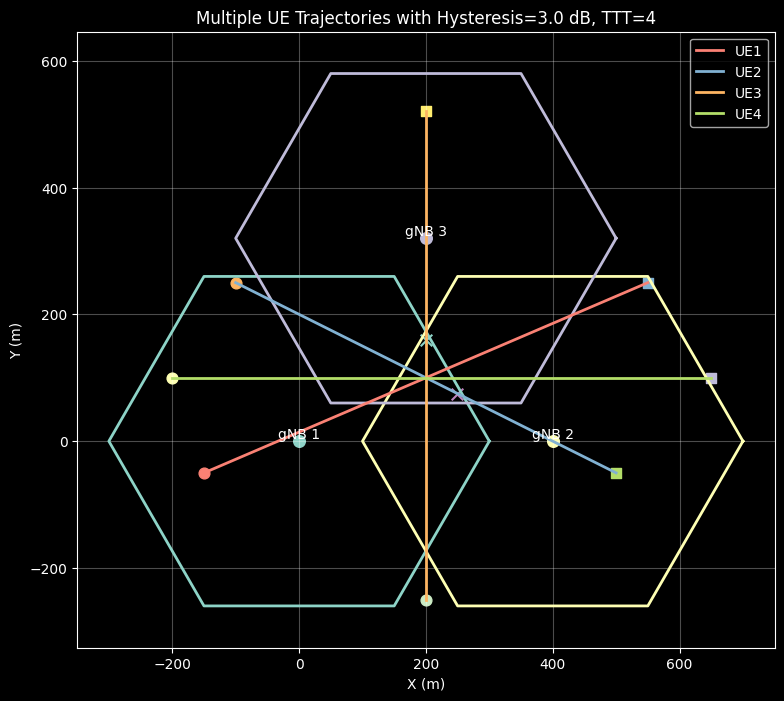

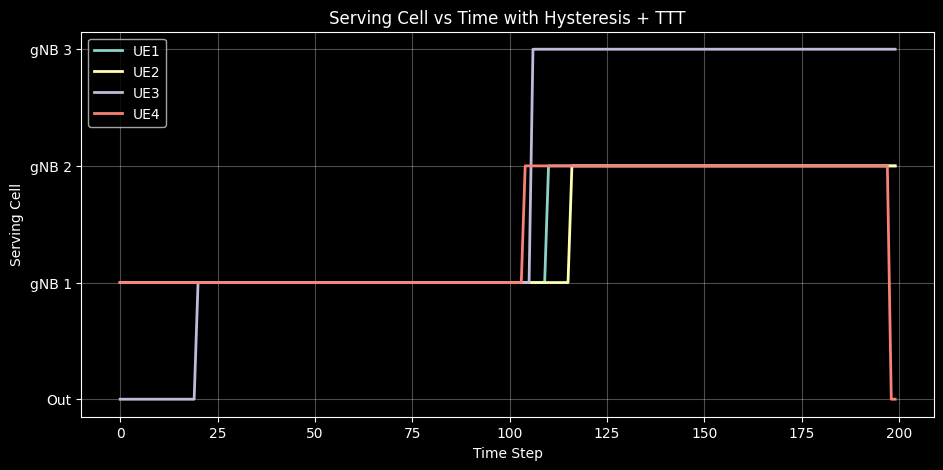

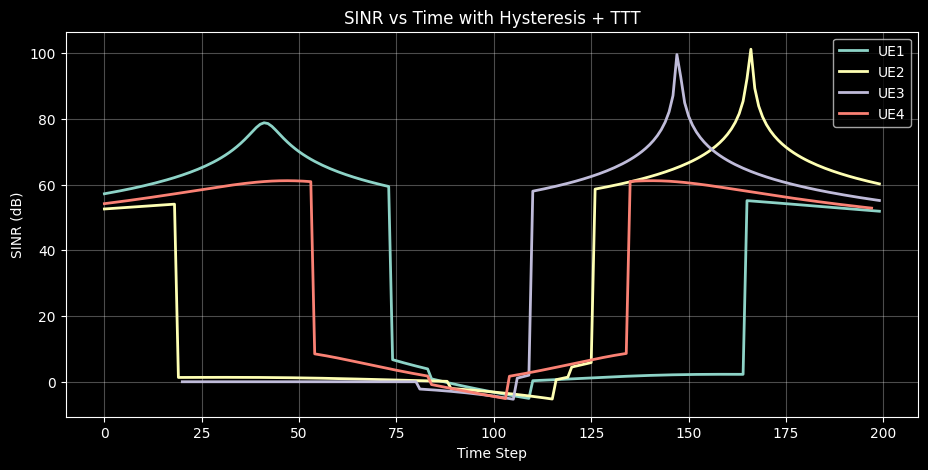

UE1: handovers=0, mean SINR=34.02 dB, handover steps=[]
UE2: handovers=1, mean SINR=30.20 dB, handover steps=[116]
UE3: handovers=1, mean SINR=31.98 dB, handover steps=[106]
UE4: handovers=0, mean SINR=35.52 dB, handover steps=[]


In [60]:
import numpy as np
import matplotlib.pyplot as plt
from node_b import NodeB

# =========================================================
# 1. Create 3 cells
# =========================================================
gnb1 = NodeB(
    id=1, x=0, y=0,
    slices_l1=[], slots_per_step=1, n_prbs=50,
    coverage_radius=300,
    carrier_id=0,
    tx_power_dbm=30.0,
    center_frequency_hz=3.5e9,
    noise_figure_db=7.0
)

gnb2 = NodeB(
    id=2, x=400, y=0,
    slices_l1=[], slots_per_step=1, n_prbs=50,
    coverage_radius=300,
    carrier_id=0,
    tx_power_dbm=30.0,
    center_frequency_hz=3.5e9,
    noise_figure_db=7.0
)

gnb3 = NodeB(
    id=3, x=200, y=320,
    slices_l1=[], slots_per_step=1, n_prbs=50,
    coverage_radius=300,
    carrier_id=0,
    tx_power_dbm=30.0,
    center_frequency_hz=3.5e9,
    noise_figure_db=7.0
)

gnbs = [gnb1, gnb2, gnb3]

# =========================================================
# 2. Parameters
# =========================================================
n_steps = 200
hysteresis_db = 3.0
ttt_steps = 4

ue_specs = [
    {"name": "UE1", "start": (-150, -50), "end": (550, 250)},
    {"name": "UE2", "start": (-100, 250), "end": (500, -50)},
    {"name": "UE3", "start": (200, -250), "end": (200, 520)},
    {"name": "UE4", "start": (-200, 100), "end": (650, 100)},
]

# =========================================================
# 3. Helpers
# =========================================================
def dbm_to_watts(p_dbm):
    if not np.isfinite(p_dbm):
        return 0.0
    return 10 ** ((p_dbm - 30.0) / 10.0)

def compute_rx_dbm(x, y, gnbs):
    return np.array([gnb.get_received_power_dbm(x, y) for gnb in gnbs], dtype=float)

def compute_sinr_from_serving(rx_dbm, serving_idx, gnbs):
    if serving_idx < 0 or not np.isfinite(rx_dbm[serving_idx]):
        return np.nan

    serving_gnb = gnbs[serving_idx]
    rx_watts = np.array([dbm_to_watts(p) for p in rx_dbm], dtype=float)

    signal_watts = rx_watts[serving_idx]

    interference_watts = 0.0
    for k, gnb in enumerate(gnbs):
        if k != serving_idx and serving_gnb.uses_same_carrier(gnb):
            interference_watts += rx_watts[k]

    noise_dbm = serving_gnb.get_noise_power_dbm()
    noise_watts = dbm_to_watts(noise_dbm)

    sinr_linear = signal_watts / (interference_watts + noise_watts)
    return 10 * np.log10(sinr_linear)

# =========================================================
# 4. Simulate multiple UEs with hysteresis + TTT
# =========================================================
results = []

for spec in ue_specs:
    x_traj = np.linspace(spec["start"][0], spec["end"][0], n_steps)
    y_traj = np.linspace(spec["start"][1], spec["end"][1], n_steps)

    serving_cells = []
    sinr_values = []
    handover_steps = []

    current_serving = -1
    candidate = -1
    candidate_counter = 0

    for t, (x, y) in enumerate(zip(x_traj, y_traj)):
        rx_dbm = compute_rx_dbm(x, y, gnbs)
        valid = np.isfinite(rx_dbm)

        if not np.any(valid):
            current_serving = -1
            candidate = -1
            candidate_counter = 0
            serving_cells.append(-1)
            sinr_values.append(np.nan)
            continue

        best_idx = int(np.nanargmax(rx_dbm))

        # initial attach
        if current_serving == -1 or not np.isfinite(rx_dbm[current_serving]):
            current_serving = best_idx
            candidate = -1
            candidate_counter = 0
        else:
            serving_power = rx_dbm[current_serving]
            best_power = rx_dbm[best_idx]

            # if best cell is different and exceeds hysteresis
            if best_idx != current_serving and best_power > serving_power + hysteresis_db:
                if candidate == best_idx:
                    candidate_counter += 1
                else:
                    candidate = best_idx
                    candidate_counter = 1

                # perform handover only after TTT
                if candidate_counter >= ttt_steps:
                    current_serving = candidate
                    handover_steps.append(t)
                    candidate = -1
                    candidate_counter = 0
            else:
                candidate = -1
                candidate_counter = 0

        serving_cells.append(current_serving)
        sinr_values.append(compute_sinr_from_serving(rx_dbm, current_serving, gnbs))

    results.append({
        "name": spec["name"],
        "x_traj": x_traj,
        "y_traj": y_traj,
        "serving_cells": np.array(serving_cells),
        "sinr_values": np.array(sinr_values),
        "handover_steps": handover_steps
    })

# =========================================================
# 5. Plot trajectories
# =========================================================
plt.figure(figsize=(9, 8))

for gnb in gnbs:
    vertices = gnb.vertices
    x_hex = [v[0] for v in vertices] + [vertices[0][0]]
    y_hex = [v[1] for v in vertices] + [vertices[0][1]]
    plt.plot(x_hex, y_hex, linewidth=2)
    plt.scatter(gnb.x, gnb.y, s=70)
    plt.text(gnb.x, gnb.y, f"gNB {gnb.id}", ha="center", va="bottom")

for res in results:
    plt.plot(res["x_traj"], res["y_traj"], linewidth=2, label=res["name"])
    plt.scatter(res["x_traj"][0], res["y_traj"][0], s=60, marker="o")
    plt.scatter(res["x_traj"][-1], res["y_traj"][-1], s=60, marker="s")
    for t in res["handover_steps"]:
        plt.scatter(res["x_traj"][t], res["y_traj"][t], s=70, marker="x")

plt.title(f"Multiple UE Trajectories with Hysteresis={hysteresis_db} dB, TTT={ttt_steps}")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# =========================================================
# 6. Serving cell vs time
# =========================================================
plt.figure(figsize=(11, 5))
for res in results:
    plt.plot(res["serving_cells"] + 1, linewidth=2, label=res["name"])

plt.yticks([0, 1, 2, 3], ["Out", "gNB 1", "gNB 2", "gNB 3"])
plt.title("Serving Cell vs Time with Hysteresis + TTT")
plt.xlabel("Time Step")
plt.ylabel("Serving Cell")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# =========================================================
# 7. SINR vs time
# =========================================================
plt.figure(figsize=(11, 5))
for res in results:
    plt.plot(res["sinr_values"], linewidth=2, label=res["name"])

plt.title("SINR vs Time with Hysteresis + TTT")
plt.xlabel("Time Step")
plt.ylabel("SINR (dB)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# =========================================================
# 8. Summary
# =========================================================
for res in results:
    valid_sinr = res["sinr_values"][np.isfinite(res["sinr_values"])]
    mean_sinr = np.mean(valid_sinr) if len(valid_sinr) > 0 else np.nan
    print(
        f"{res['name']}: handovers={len(res['handover_steps'])}, "
        f"mean SINR={mean_sinr:.2f} dB, "
        f"handover steps={res['handover_steps']}"
    )